In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import features as ft
import re
import pyarrow

In [2]:
features_df = pd.read_parquet(r"C:\Users\LENOVO\OneDrive\Documentos\Estancia de Investigación\PopocatepetlVolcano\data\features.parquet", engine="pyarrow")

# Chunk de una hora

In [3]:
hours = 1
# clustering_data = features_raw_df.copy()
# Apply filters to the time series of the features
features_df = features_df[(features_df['energy']>=0)&(features_df['kurtosis']<2500)&(features_df['frequency_index']>=-3)&(features_df['entropy']>=0)&(features_df['entropy']<15000)]
# Calculate moving average for all features
features_df['energy_movil_media'] = np.log10(features_df['energy'].rolling(window=11*hours, center=False).mean())
features_df['kurtosis_mobile_mean'] = np.log10(features_df['kurtosis'].rolling(window=11*hours, center=False).mean())
features_df['frequency_index_movil_media'] = features_df['frequency_index'].rolling(window=11*hours, center=False).mean()
features_df['entropy_movil_media'] = features_df['entropy'].rolling(window=11*hours, center=False).mean()

features_df['energy'] = np.log10(features_df['energy'])
features_df['kurtosis'] = np.log10(features_df['kurtosis'])


In [4]:
features_df_1_month = features_df[features_df['timestamp']<"2022-02-01"]

features_df_1_month

,timestamp,energy,kurtosis,frecuency_index,entropy,frequency_index,energy_movil_media,kurtosis_mobile_mean,frequency_index_movil_media,entropy_movil_media
0,2022-01-01 00:05:00,7.074324,0.633977,None,6743.988806,-0.005959,NaN,NaN,NaN,NaN
1,2022-01-01 00:10:00,7.020175,0.632777,None,7043.316623,-0.109812,NaN,NaN,NaN,NaN
2,2022-01-01 00:15:00,7.011306,0.751629,None,7175.473832,0.032564,NaN,NaN,NaN,NaN
3,2022-01-01 00:20:00,7.010472,0.750180,None,7186.277967,0.065660,NaN,NaN,NaN,NaN
4,2022-01-01 00:25:00,6.986411,0.732571,None,7290.097859,-0.179743,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
8892,2022-01-31 23:35:00,8.830721,2.334161,None,1668.982751,0.629002,8.471704,1.573340,0.347591,2194.681709
8893,2022-01-31 23:40:00,8.817154,2.361190,None,1705.372009,0.451853,8.512201,1.760099,0.385613,2178.716875
8894,2022-01-31 23:45:00,8.051987,0.780485,None,2927.230991,0.083474,8.474237,1.714692,0.360933,2273.282381
8895,2022-01-31 23:50:00,7.990021,0.815191,None,3100.668472,0.158434,8.432990,1.659252,0.330689,2379.334500


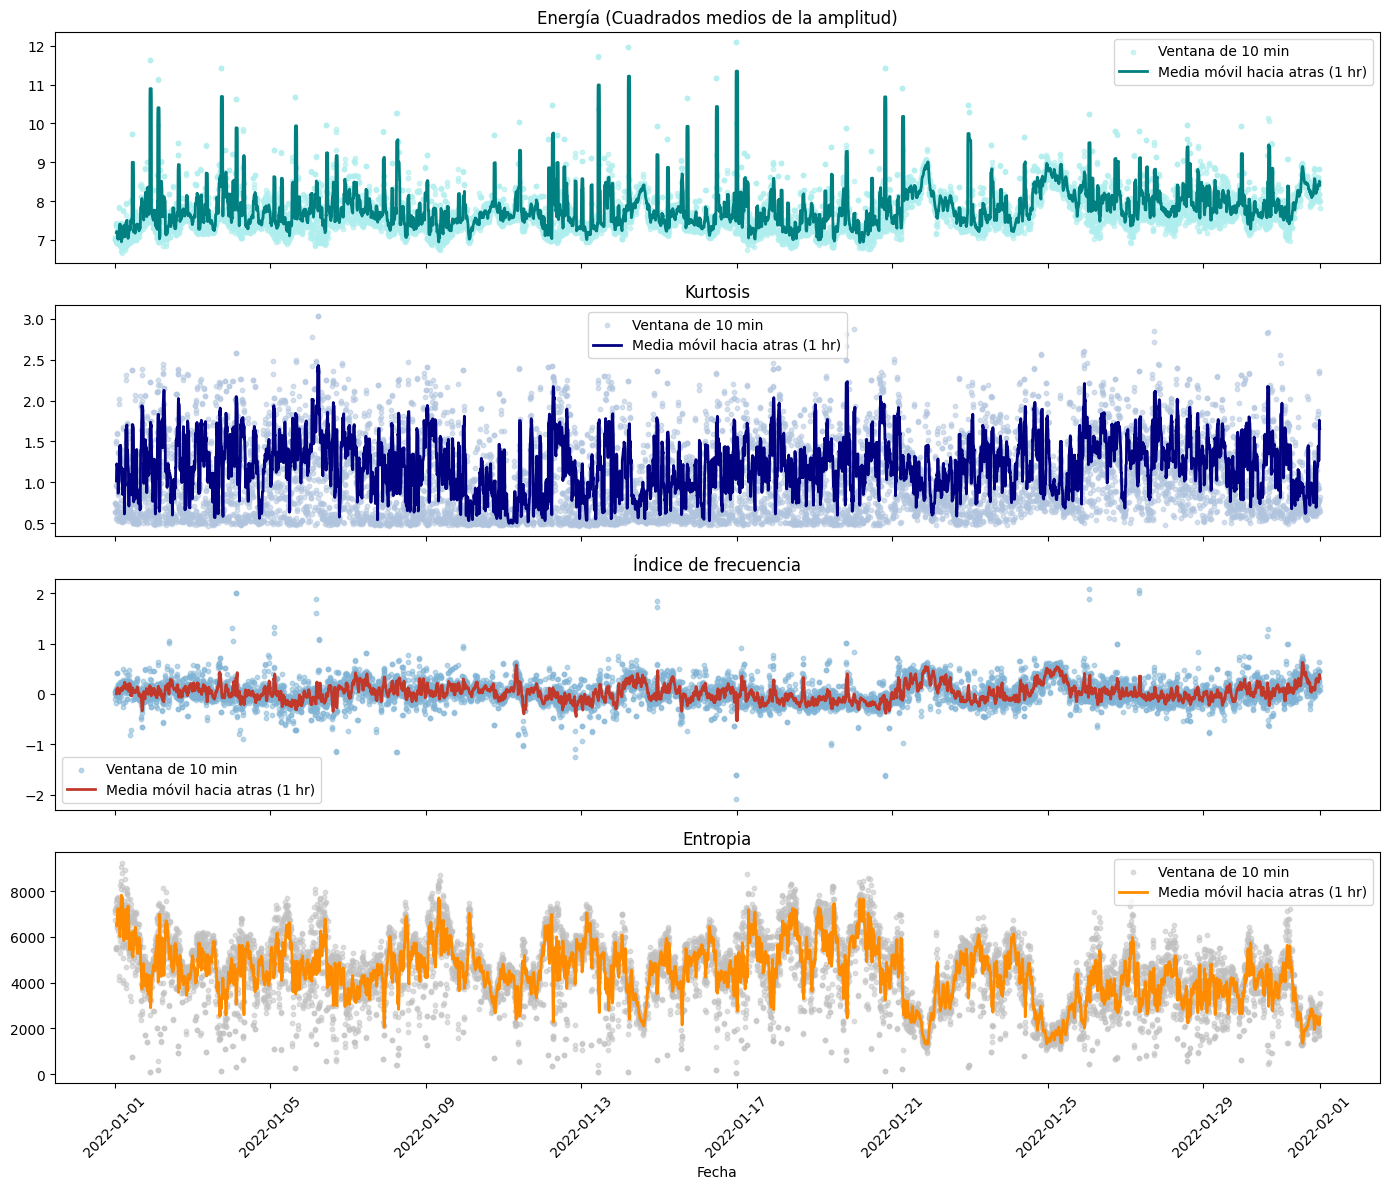

In [5]:
# Generate the plot
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(14, 12), sharex=True)
axes[0].scatter(features_df_1_month['timestamp'], features_df_1_month['energy'], color='paleturquoise', s=10, alpha=0.6, label="Ventana de 10 min")
axes[0].plot(features_df_1_month['timestamp'], features_df_1_month['energy_movil_media'], color='teal', linewidth=2, label= f'Media móvil hacia atras ({hours} hr)')
axes[0].set_title('Energía (Cuadrados medios de la amplitud)')
axes[0].legend(loc='best')

axes[1].scatter(features_df_1_month['timestamp'], features_df_1_month['kurtosis'], color='lightsteelblue', s=10, alpha=0.5, label = "Ventana de 10 min")
axes[1].plot(features_df_1_month['timestamp'], features_df_1_month['kurtosis_mobile_mean'], color='navy', alpha = 1,linewidth=2, label= f'Media móvil hacia atras ({hours} hr)')
axes[1].set_title('Kurtosis')
axes[1].legend(loc='best')

axes[2].scatter(features_df_1_month['timestamp'], features_df_1_month['frequency_index'], color='#7FB3D5', s=10, alpha=0.5, label = "Ventana de 10 min")
axes[2].plot(features_df_1_month['timestamp'], features_df_1_month['frequency_index_movil_media'], color='#C0392B', alpha = 1,linewidth=2, label= f'Media móvil hacia atras ({hours} hr)')
axes[2].set_title('Índice de frecuencia')
axes[2].legend(loc='best')

axes[3].scatter(features_df_1_month['timestamp'], features_df_1_month['entropy'], color='silver', s=10, alpha=0.5, label = "Ventana de 10 min")
axes[3].plot(features_df_1_month['timestamp'], features_df_1_month['entropy_movil_media'], color='darkorange', alpha = 1,linewidth=2, label= f'Media móvil hacia atras ({hours} hr)')
axes[3].set_title('Entropia')
axes[3].set_xlabel('Fecha')
axes[3].legend(loc='best')

plt.xticks(rotation=45)
plt.tight_layout()

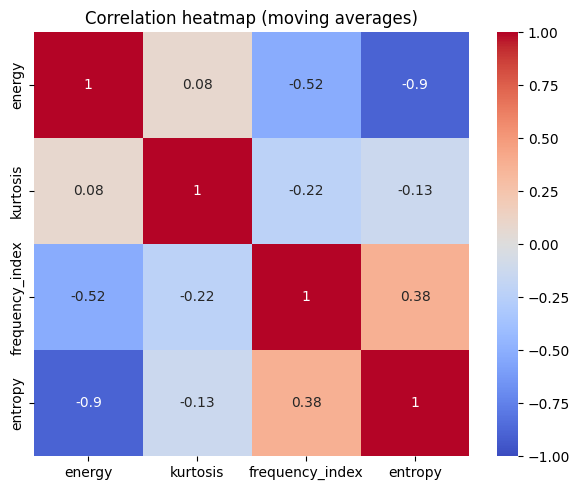

In [6]:
import seaborn as sns

# Select the four moving-average feature columns and drop missing values
corr_df = features_df[[
    'energy',
    'kurtosis',
    'frequency_index',
    'entropy'
]].dropna()
# Compute correlation matrix
corr = corr_df.corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation heatmap (moving averages)')
plt.tight_layout()
plt.show()

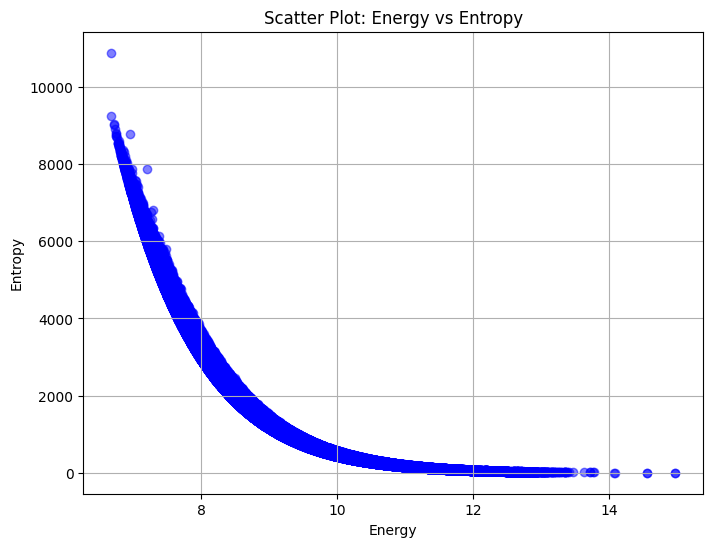

In [7]:
plt.figure(figsize=(8, 6))
plt.scatter(features_df['energy'], features_df['entropy'], alpha=0.5, c='blue')
plt.title('Scatter Plot: Energy vs Entropy')
plt.xlabel('Energy')
plt.ylabel('Entropy')
plt.grid(True)
plt.show()

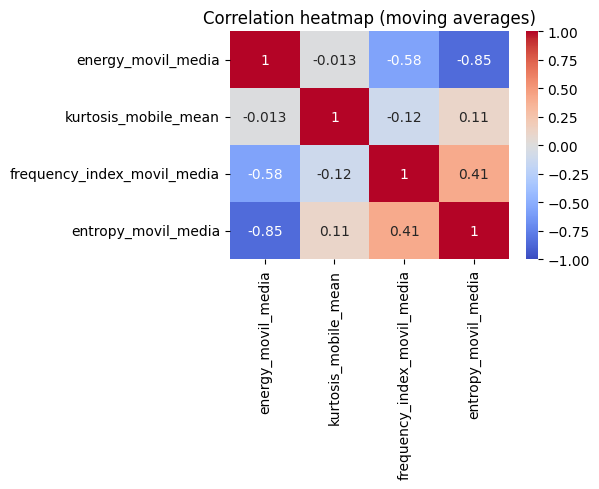

In [8]:
import seaborn as sns
# Select the four moving-average feature columns and drop missing values
corr_df = features_df[[
    'energy_movil_media',
    'kurtosis_mobile_mean',
    'frequency_index_movil_media',
    'entropy_movil_media'
]].dropna()
# Compute correlation matrix
corr = corr_df.corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation heatmap (moving averages)')
plt.tight_layout()
plt.show()

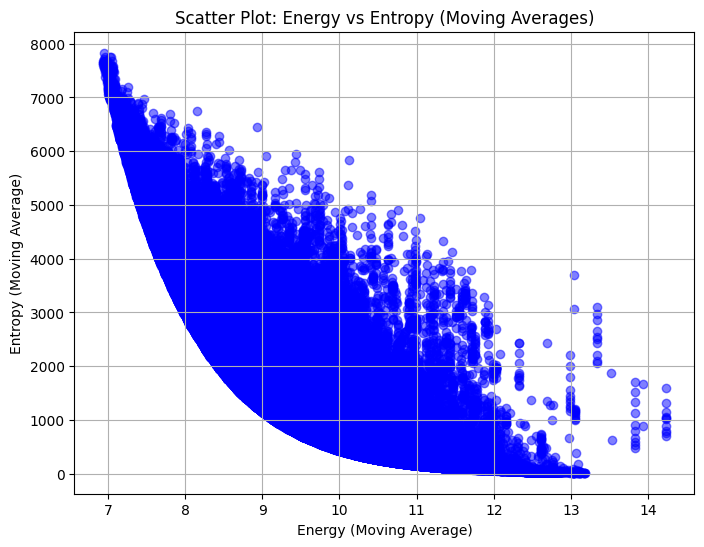

In [9]:
# Generate a scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(features_df['energy_movil_media'], features_df['entropy_movil_media'], alpha=0.5, c='blue')
plt.title('Scatter Plot: Energy vs Entropy (Moving Averages)')
plt.xlabel('Energy (Moving Average)')
plt.ylabel('Entropy (Moving Average)')
plt.grid(True)
plt.show()


In [10]:
from sklearn.model_selection import GridSearchCV
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import make_pipeline

In [11]:
clustering_data = features_df_1_month[
    [
        'energy_movil_media',
        'kurtosis_mobile_mean',
        'frequency_index_movil_media',
        'entropy_movil_media'
    ]
]

# Drop rows with missing values
clustering_data = clustering_data.dropna()

# Select columns to scale
cols_to_scale =  [
        'energy_movil_media',
        'kurtosis_mobile_mean',
        'frequency_index_movil_media',
        'entropy_movil_media'
    ]

# Crea y entrena un escalador (Robust scaler)
scaler = MinMaxScaler()
#scaler.fit(clustering_data)

scaled_data = scaler.fit_transform(clustering_data[cols_to_scale])

# 4. Convert the NumPy array back to a DataFrame and maintain index/columns
df_scaled = pd.DataFrame(scaled_data, columns=cols_to_scale, index=clustering_data.index)


# 4. Convert the NumPy array back to a DataFrame and maintain index/columns



#clustering_data['timestamp'] = features_df['timestamp']



# Take a random sample of 50,000 rows from the clustering data

#clustering_data = clustering_data.sample(n=50000, random_state=42)

X = df_scaled[
    [
        'energy_movil_media',
        'kurtosis_mobile_mean',
        'frequency_index_movil_media',
        'entropy_movil_media'
    ]
]



In [12]:
X

,energy_movil_media,kurtosis_mobile_mean,frequency_index_movil_media,entropy_movil_media
10,0.058479,0.268296,0.461650,0.805977
11,0.061245,0.329630,0.494064,0.802114
12,0.064766,0.376563,0.535107,0.793323
13,0.064163,0.374444,0.538246,0.795884
14,0.063019,0.372058,0.530870,0.802242
...,...,...,...,...
8892,0.348772,0.556317,0.759879,0.135711
8893,0.357943,0.652961,0.792768,0.133264
8894,0.349346,0.629463,0.771420,0.147761
8895,0.340005,0.600774,0.745260,0.164018


In [13]:
# Trata con differentes valores para k
inertia = []
silh = []
k_s = np.arange(2, 16)
for k in k_s:
  km_model = KMeans(n_clusters=k).fit(X)
  inertia.append(km_model.inertia_)
  silh.append(silhouette_score(X, km_model.labels_))

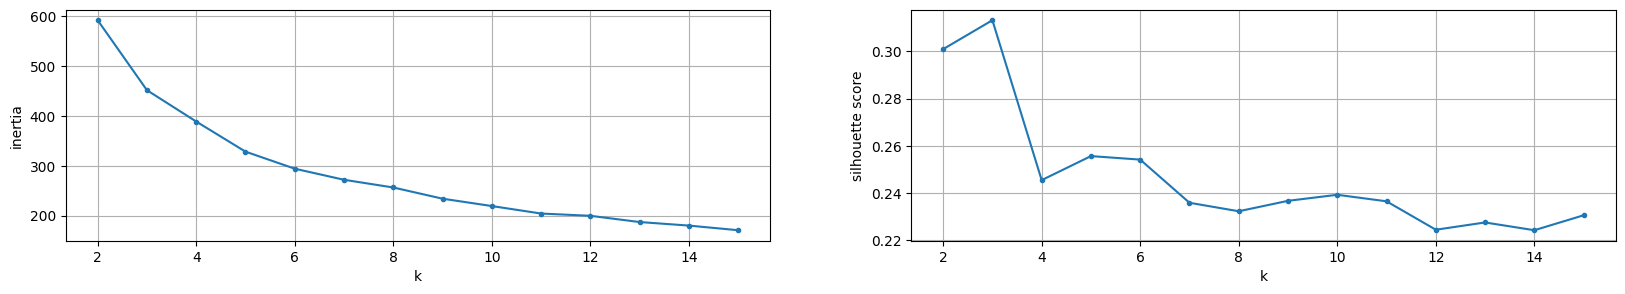

In [14]:
# Plot results
plt.figure(figsize=(20, 3))
plt.subplot(1, 2, 1)
plt.plot(k_s, inertia, '.-')
plt.grid()
plt.xlabel('k')
plt.ylabel('inertia')
plt.subplot(1, 2, 2)
plt.plot(k_s, silh, '.-')
plt.grid()
plt.xlabel('k')
plt.ylabel('silhouette score')
plt.show()

In [15]:
# Repite k-means con el mejor número k
km_model = KMeans(n_clusters=3).fit(X)

clustering_data = X
clustering_data['timestamp'] = features_df['timestamp']

clustering_data['labels'] = km_model.labels_

<Figure size 1600x1200 with 0 Axes>

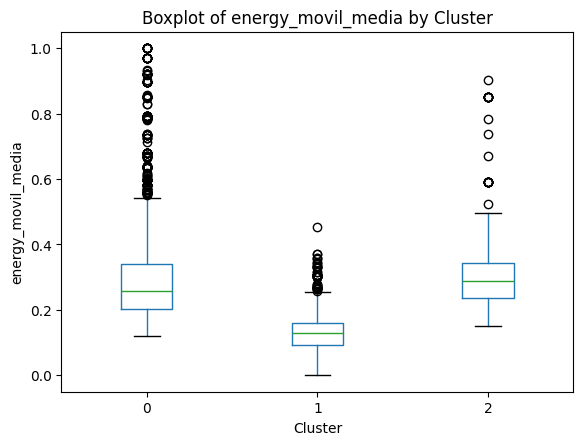

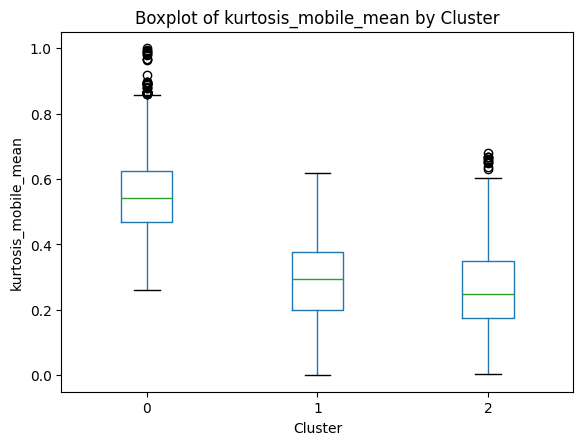

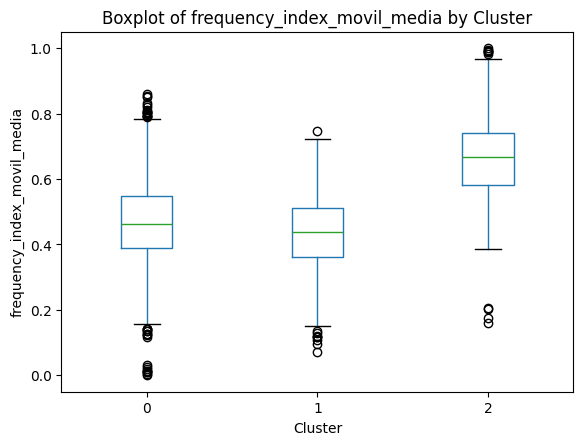

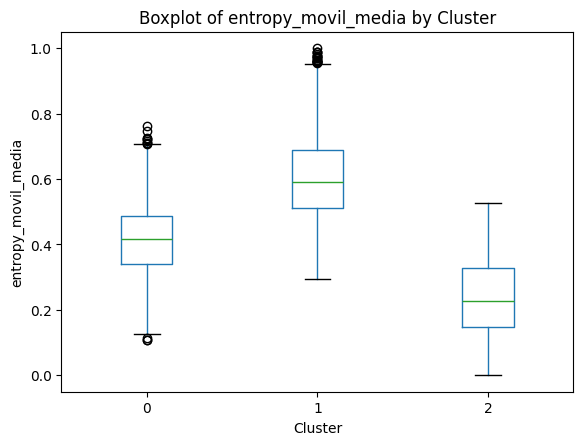

In [16]:
# Generate boxplots for each column grouped by cluster label
columns_to_plot = [
    'energy_movil_media',
    'kurtosis_mobile_mean',
    'frequency_index_movil_media',
    'entropy_movil_media'
    ]

plt.figure(figsize=(16, 12))
for column in columns_to_plot:
    clustering_data.boxplot(column=column, by='labels', grid=False)
    plt.title(f'Boxplot of {column} by Cluster')
    plt.suptitle('')  # Suppress the default title
    plt.xlabel('Cluster')
    plt.ylabel(column)

plt.show()

In [17]:
# Sort clustering data by timestamp
clustering_data = clustering_data.sort_values(by='timestamp')

In [18]:
clustering_data[['labels','timestamp']].groupby('labels').count()

,timestamp
labels,
0,3230
1,4244
2,1409


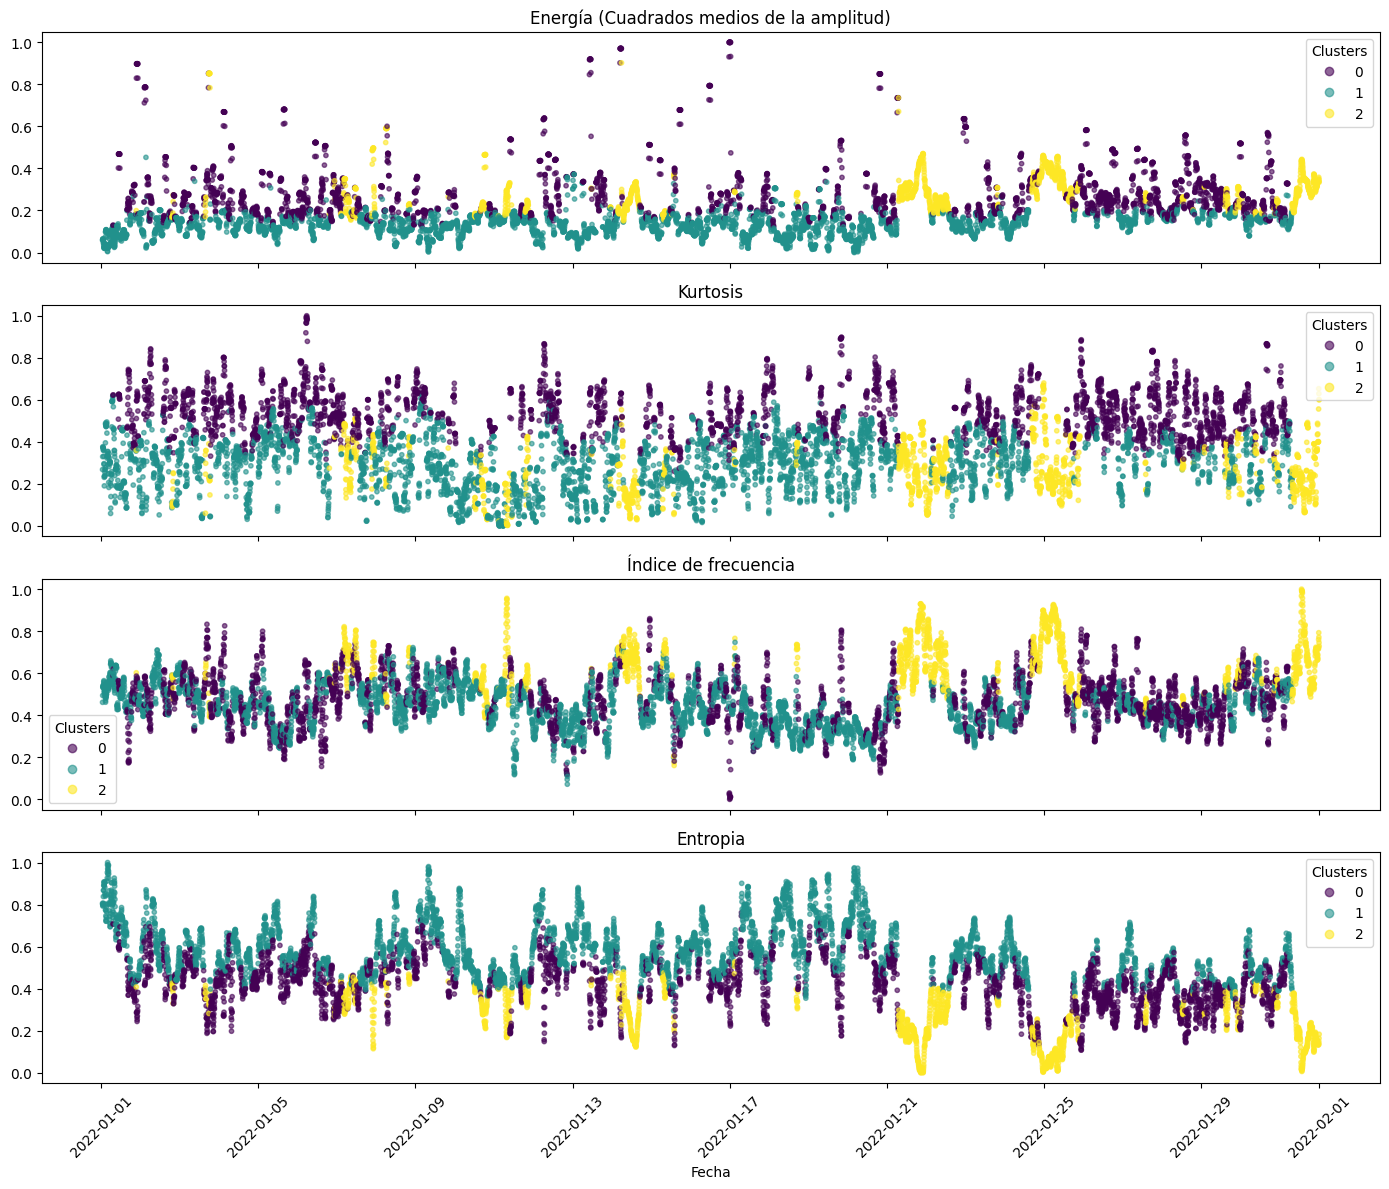

In [19]:
# Generate the plot
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(14, 12), sharex=True)
scatter = axes[0].scatter(clustering_data['timestamp'], clustering_data['energy_movil_media'], c=clustering_data['labels'], cmap='viridis', s=10, alpha=0.6)
axes[0].set_title('Energía (Cuadrados medios de la amplitud)')
axes[0].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[1].scatter(clustering_data['timestamp'], clustering_data['kurtosis_mobile_mean'], c=clustering_data['labels'], cmap='viridis', s=10, alpha=0.6)
axes[1].set_title('Kurtosis')
axes[1].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[2].scatter(clustering_data['timestamp'], clustering_data['frequency_index_movil_media'], c=clustering_data['labels'], cmap='viridis', s=10, alpha=0.6)
axes[2].set_title('Índice de frecuencia')
axes[2].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[3].scatter(clustering_data['timestamp'], clustering_data['entropy_movil_media'], c=clustering_data['labels'], cmap='viridis', s=10, alpha=0.6)
axes[3].set_title('Entropia')
axes[3].set_xlabel('Fecha')
axes[3].legend(*scatter.legend_elements(), title="Clusters")

plt.xticks(rotation=45)
plt.tight_layout()

In [22]:
features_df_2nd_month = features_df[(features_df['timestamp']<"2022-03-01") & (features_df['timestamp']>="2022-02-01")]

clustering_data_2 = features_df_2nd_month[
    [
        'energy_movil_media',
        'kurtosis_mobile_mean',
        'frequency_index_movil_media',
        'entropy_movil_media'
    ]
]

# Drop rows with missing values
clustering_data_2 = clustering_data_2.dropna()


scaled_data_2 = scaler.transform(clustering_data_2[cols_to_scale])

# 4. Convert the NumPy array back to a DataFrame and maintain index/columns
df_scaled_2 = pd.DataFrame(scaled_data_2, columns=cols_to_scale, index=clustering_data_2.index)


# 4. Convert the NumPy array back to a DataFrame and maintain index/columns



#clustering_data['timestamp'] = features_df['timestamp']



# Take a random sample of 50,000 rows from the clustering data

#clustering_data = clustering_data.sample(n=50000, random_state=42)

X_2 = df_scaled_2[
    [
        'energy_movil_media',
        'kurtosis_mobile_mean',
        'frequency_index_movil_media',
        'entropy_movil_media'
    ]
]



X_2

,energy_movil_media,kurtosis_mobile_mean,frequency_index_movil_media,entropy_movil_media
8897,0.331133,0.601783,0.696054,0.193041
8898,0.325384,0.601695,0.676614,0.202813
8899,0.317116,0.601643,0.660915,0.216007
8900,0.314114,0.601459,0.650414,0.225646
8901,0.316521,0.660813,0.597366,0.223072
...,...,...,...,...
16928,0.431228,0.342590,0.296538,0.018747
16929,0.423762,0.350566,0.303134,0.038322
16930,0.413340,0.361180,0.334069,0.073263
16931,0.404716,0.370297,0.344488,0.095809


In [23]:
# Predict clusters for new data using the same centroids
labels_2 = km_model.predict(X_2)

# Add labels and timestamp to the new dataframe
clustering_data_2 = X_2.copy()
clustering_data_2['timestamp'] = features_df_2nd_month['timestamp']
clustering_data_2['labels'] = labels_2

In [25]:
clustering_data_all = pd.concat([clustering_data, clustering_data_2], axis=0)

# Optional: sort by timestamp
clustering_data_all = clustering_data_all.sort_values('timestamp')

clustering_data_all

,energy_movil_media,kurtosis_mobile_mean,frequency_index_movil_media,entropy_movil_media,timestamp,labels
10,0.058479,0.268296,0.461650,0.805977,2022-01-01 00:55:00,1
11,0.061245,0.329630,0.494064,0.802114,2022-01-01 01:00:00,1
12,0.064766,0.376563,0.535107,0.793323,2022-01-01 01:05:00,1
13,0.064163,0.374444,0.538246,0.795884,2022-01-01 01:10:00,1
14,0.063019,0.372058,0.530870,0.802242,2022-01-01 01:15:00,1
...,...,...,...,...,...,...
16928,0.431228,0.342590,0.296538,0.018747,2022-02-28 23:35:00,2
16929,0.423762,0.350566,0.303134,0.038322,2022-02-28 23:40:00,2
16930,0.413340,0.361180,0.334069,0.073263,2022-02-28 23:45:00,2
16931,0.404716,0.370297,0.344488,0.095809,2022-02-28 23:50:00,2


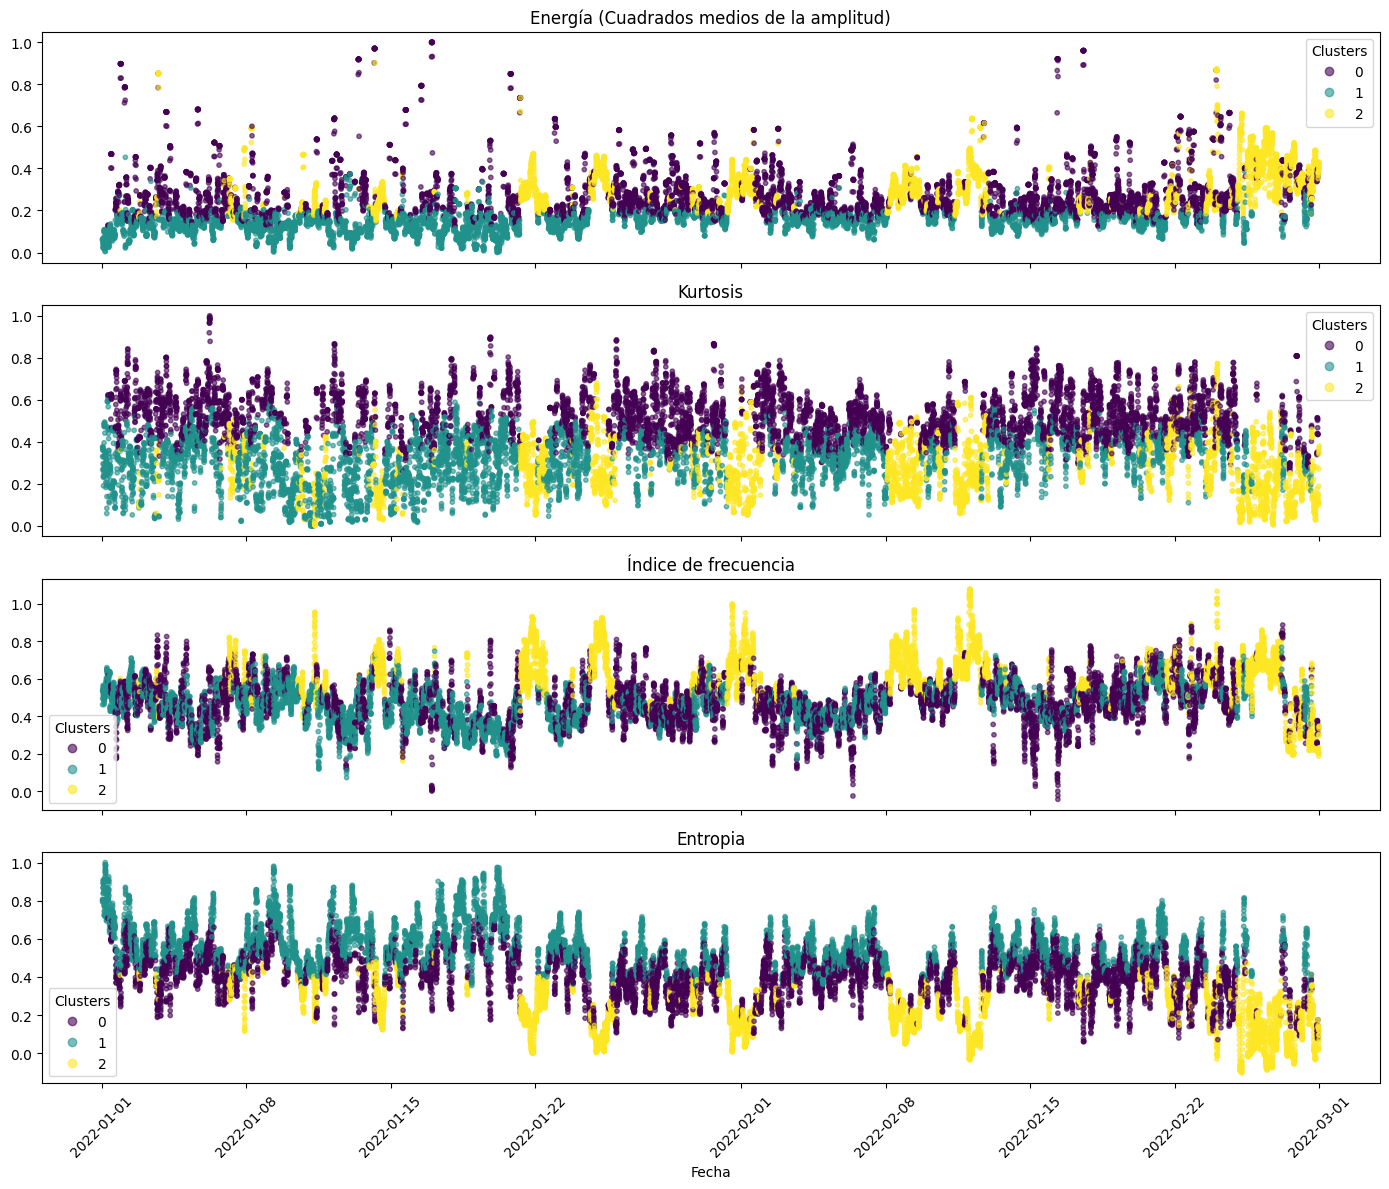

In [26]:
# Generate the plot
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(14, 12), sharex=True)
scatter = axes[0].scatter(clustering_data_all['timestamp'], clustering_data_all['energy_movil_media'], c=clustering_data_all['labels'], cmap='viridis', s=10, alpha=0.6)
axes[0].set_title('Energía (Cuadrados medios de la amplitud)')
axes[0].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[1].scatter(clustering_data_all['timestamp'], clustering_data_all['kurtosis_mobile_mean'], c=clustering_data_all['labels'], cmap='viridis', s=10, alpha=0.6)
axes[1].set_title('Kurtosis')
axes[1].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[2].scatter(clustering_data_all['timestamp'], clustering_data_all['frequency_index_movil_media'], c=clustering_data_all['labels'], cmap='viridis', s=10, alpha=0.6)
axes[2].set_title('Índice de frecuencia')
axes[2].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[3].scatter(clustering_data_all['timestamp'], clustering_data_all['entropy_movil_media'], c=clustering_data_all['labels'], cmap='viridis', s=10, alpha=0.6)
axes[3].set_title('Entropia')
axes[3].set_xlabel('Fecha')
axes[3].legend(*scatter.legend_elements(), title="Clusters")

plt.xticks(rotation=45)
plt.tight_layout()

In [27]:
features_df_rest_all = features_df[ (features_df['timestamp']>="2022-03-01")]

clustering_data_3 = features_df_rest_all[
    [
        'energy_movil_media',
        'kurtosis_mobile_mean',
        'frequency_index_movil_media',
        'entropy_movil_media'
    ]
]

# Drop rows with missing values
clustering_data_3 = clustering_data_3.dropna()


scaled_data_3 = scaler.transform(clustering_data_3[cols_to_scale])

# 4. Convert the NumPy array back to a DataFrame and maintain index/columns
df_scaled_3 = pd.DataFrame(scaled_data_3, columns=cols_to_scale, index=clustering_data_3.index)


# 4. Convert the NumPy array back to a DataFrame and maintain index/columns



#clustering_data['timestamp'] = features_df['timestamp']



# Take a random sample of 50,000 rows from the clustering data

#clustering_data = clustering_data.sample(n=50000, random_state=42)

X_3 = df_scaled_3[
    [
        'energy_movil_media',
        'kurtosis_mobile_mean',
        'frequency_index_movil_media',
        'entropy_movil_media'
    ]
]



X_3

,energy_movil_media,kurtosis_mobile_mean,frequency_index_movil_media,entropy_movil_media
16933,0.390132,0.409278,0.356620,0.129608
16934,0.384422,0.413339,0.359737,0.138495
16935,0.378792,0.419682,0.364113,0.149224
16936,0.364854,0.408829,0.364219,0.160651
16937,0.351838,0.393845,0.365469,0.166779
...,...,...,...,...
244232,0.349573,0.601685,0.601527,0.170613
244233,0.354966,0.638621,0.583202,0.165901
244234,0.337173,0.609883,0.594741,0.176824
244235,0.318117,0.567649,0.608853,0.185523


In [28]:
# Predict clusters for new data using the same centroids
labels_3 = km_model.predict(X_3)

# Add labels and timestamp to the new dataframe
clustering_data_3 = X_3.copy()
clustering_data_3['timestamp'] = features_df_rest_all['timestamp']
clustering_data_3['labels'] = labels_3

clustering_data_all_with_rest = pd.concat([clustering_data_all, clustering_data_3], axis=0)

# Optional: sort by timestamp
clustering_data_all_with_rest = clustering_data_all_with_rest.sort_values('timestamp')

clustering_data_all_with_rest


,energy_movil_media,kurtosis_mobile_mean,frequency_index_movil_media,entropy_movil_media,timestamp,labels
10,0.058479,0.268296,0.461650,0.805977,2022-01-01 00:55:00,1
11,0.061245,0.329630,0.494064,0.802114,2022-01-01 01:00:00,1
12,0.064766,0.376563,0.535107,0.793323,2022-01-01 01:05:00,1
13,0.064163,0.374444,0.538246,0.795884,2022-01-01 01:10:00,1
14,0.063019,0.372058,0.530870,0.802242,2022-01-01 01:15:00,1
...,...,...,...,...,...,...
244232,0.349573,0.601685,0.601527,0.170613,2024-04-30 23:35:00,0
244233,0.354966,0.638621,0.583202,0.165901,2024-04-30 23:40:00,0
244234,0.337173,0.609883,0.594741,0.176824,2024-04-30 23:45:00,0
244235,0.318117,0.567649,0.608853,0.185523,2024-04-30 23:50:00,0


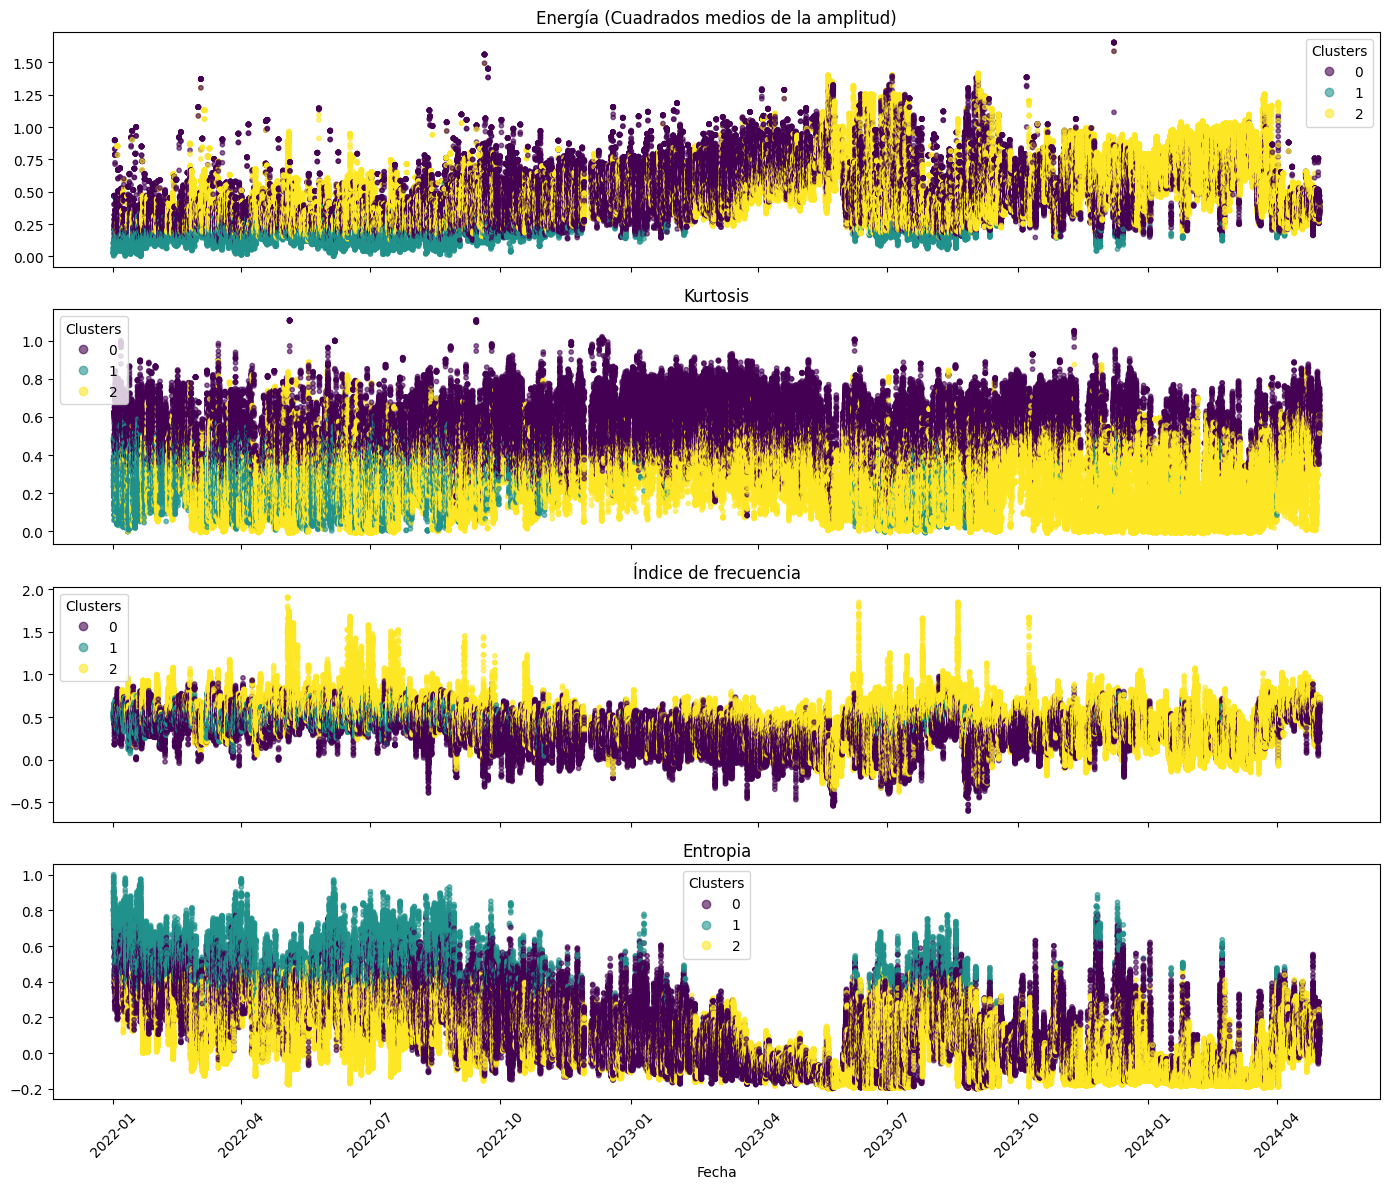

In [29]:
# Generate the plot
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(14, 12), sharex=True)
scatter = axes[0].scatter(clustering_data_all_with_rest['timestamp'], clustering_data_all_with_rest['energy_movil_media'], c=clustering_data_all_with_rest['labels'], cmap='viridis', s=10, alpha=0.6)
axes[0].set_title('Energía (Cuadrados medios de la amplitud)')
axes[0].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[1].scatter(clustering_data_all_with_rest['timestamp'], clustering_data_all_with_rest['kurtosis_mobile_mean'], c=clustering_data_all_with_rest['labels'], cmap='viridis', s=10, alpha=0.6)
axes[1].set_title('Kurtosis')
axes[1].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[2].scatter(clustering_data_all_with_rest['timestamp'], clustering_data_all_with_rest['frequency_index_movil_media'], c=clustering_data_all_with_rest['labels'], cmap='viridis', s=10, alpha=0.6)
axes[2].set_title('Índice de frecuencia')
axes[2].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[3].scatter(clustering_data_all_with_rest['timestamp'], clustering_data_all_with_rest['entropy_movil_media'], c=clustering_data_all_with_rest['labels'], cmap='viridis', s=10, alpha=0.6)
axes[3].set_title('Entropia')
axes[3].set_xlabel('Fecha')
axes[3].legend(*scatter.legend_elements(), title="Clusters")

plt.xticks(rotation=45)
plt.tight_layout()